In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
!gdown 1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m

Using cookies from C:\Users\pawan\.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1uUt7uL-VuF_5cpodYRiriEwhsldeEp3m
To: c:\Users\pawan\DataScience_GIT\DataScience\LinearRegression\churn_logistic.csv

  0%|          | 0.00/494k [00:00<?, ?B/s]
100%|██████████| 494k/494k [00:00<00:00, 2.49MB/s]
100%|██████████| 494k/494k [00:00<00:00, 2.47MB/s]


In [4]:
import pandas as pd

In [5]:
churn = pd.read_csv("churn_logistic.csv")
churn.head()

,Account Length,VMail Message,Day Mins,Eve Mins,Night Mins,Intl Mins,CustServ Calls,Intl Plan,VMail Plan,Day Calls,...,Eve Calls,Eve Charge,Night Calls,Night Charge,Intl Calls,Intl Charge,State,Area Code,Phone,Churn
0,128,25,265.1,197.4,244.7,10.0,1,0,1,110,...,99,16.78,91,11.01,3,2.70,KS,415,382-4657,0
1,107,26,161.6,195.5,254.4,13.7,1,0,1,123,...,103,16.62,103,11.45,3,3.70,OH,415,371-7191,0
2,137,0,243.4,121.2,162.6,12.2,0,0,0,114,...,110,10.30,104,7.32,5,3.29,NJ,415,358-1921,0
3,84,0,299.4,61.9,196.9,6.6,2,1,0,71,...,88,5.26,89,8.86,7,1.78,OH,408,375-9999,0
4,75,0,166.7,148.3,186.9,10.1,3,1,0,113,...,122,12.61,121,8.41,3,2.73,OK,415,330-6626,0


**Data Description**
<center>

| Records | Features |
| :-- | :-- |
| 5700 | 21 |


| Id | Features | Description |
| :-- | :--| :--|
|01| **state** | 2-letter code of the US state of customer residence|
|02| **account_length** | Number of months the customer has been with the current telco provider |
|03|**area_code**|string="area_code_AAA" where AAA = 3 digit area code|
|04|**intl_plan**|The customer has international plan|
|05|**vmail_plan**| The customer has voice mail plan|
|06|**vmail_messages**|Number of voice-mail messages|
|07|**day_mins**|Total minutes of day calls|
|08|**day_calls**|Total no of day calls|
|09|**day_charge**|Total charge of day calls|
|10|**eve_mins**|Total minutes of evening calls|
|11|**eve_calls**|Total no of evening calls|
|12|**eve_charge**|Total charge of evening calls|
|13|**night_mins**|Total minutes of night calls|
|14|**night_calls**|Total no of night calls|
|15|**night_charge**|Total charge of night calls|
|16|**intl_mins**|Total minutes of international calls|
|17|**intl_calls**|Total no of international calls|
|18|**intl_charge**|Total charge of international calls|
|19|**customer_service_calls**|Number of calls to customer service|
|20|**phone**|10 digit number|
|21|**churn**|Customer churn - target variable|

In [6]:
churn["Churn"].value_counts()

Churn
0    2850
1    2850
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='Day Mins'>

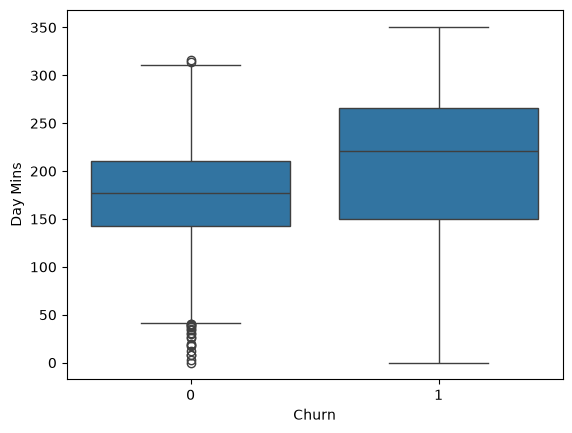

In [11]:
import seaborn as sns

sns.boxplot(x="Churn", y="Day Mins", data = churn)

Day Mins is important feature. lets check its collinearity with other features.

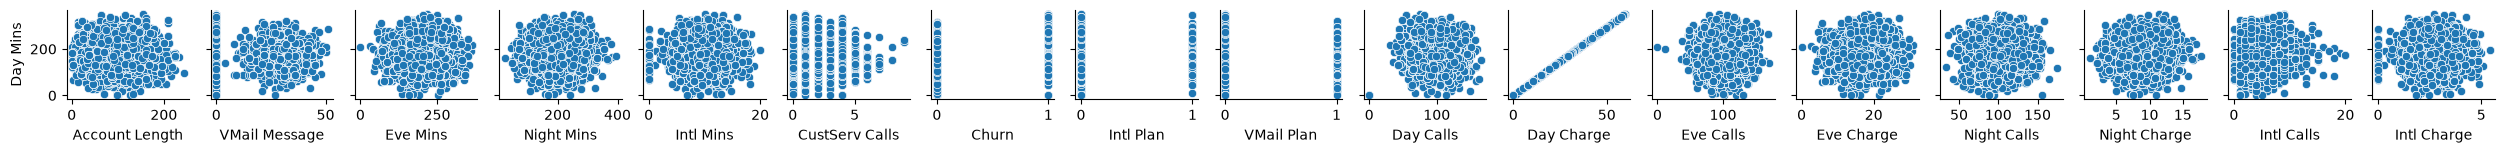

In [14]:
sns.pairplot(data=churn, y_vars=['Day Mins'], x_vars=['Account Length', 'VMail Message' , 'Eve Mins', 'Night Mins',
       'Intl Mins', 'CustServ Calls', 'Churn', 'Intl Plan', 'VMail Plan',
       'Day Calls', 'Day Charge', 'Eve Calls', 'Eve Charge', 'Night Calls',
       'Night Charge', 'Intl Calls', 'Intl Charge'],height=1.5,aspect=1)
plt.show()

Day Mins is highly correlated with Day charge. we will drop Day charge column

<Axes: xlabel='Churn', ylabel='Account Length'>

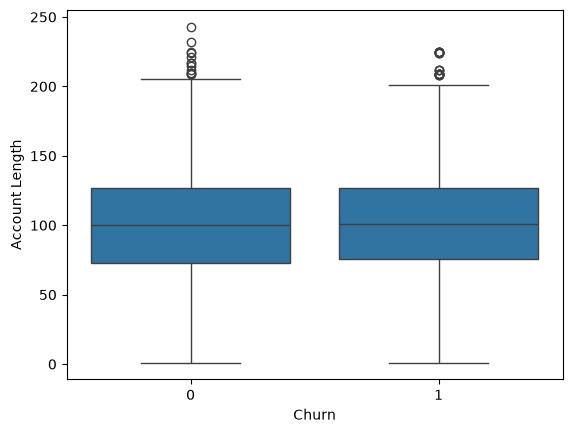

In [15]:
# check for column Account length
sns.boxplot(x="Churn", y="Account Length", data = churn)

this feature is not useful for our model as the boxplot shows that the median of both the classes is almost same. So we can drop this column from our dataset.

<Axes: xlabel='Churn', ylabel='Eve Mins'>

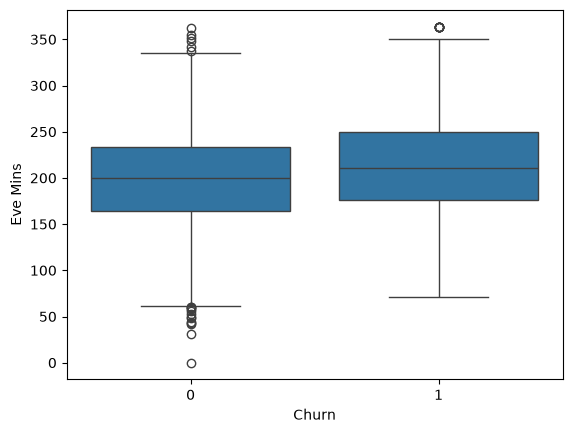

In [17]:
sns.boxplot(x='Churn',y='Eve Mins',data=churn)

<Axes: xlabel='Churn', ylabel='Intl Plan'>

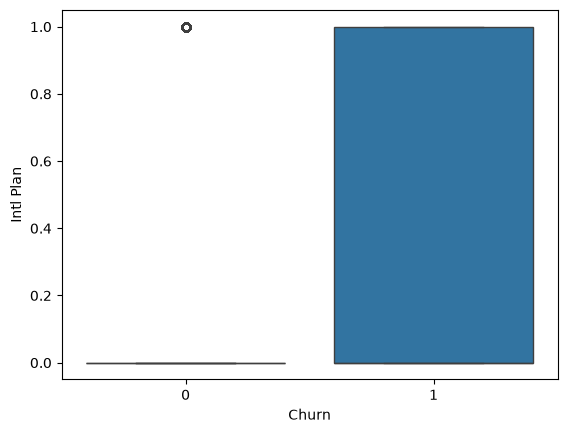

In [18]:
sns.boxplot(x='Churn',y='Intl Plan',data=churn)

<Axes: xlabel='Churn', ylabel='CustServ Calls'>

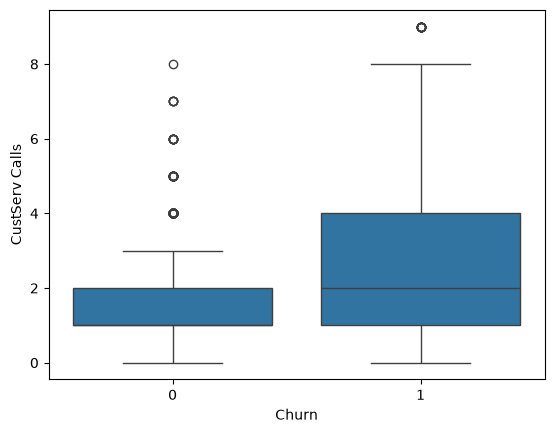

In [19]:
sns.boxplot(x="Churn", y="CustServ Calls", data = churn)

<Axes: xlabel='Churn', ylabel='VMail Message'>

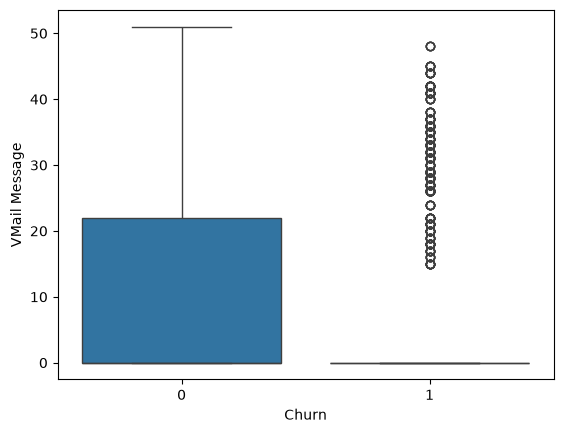

In [21]:
sns.boxplot(x="Churn", y="VMail Message", data = churn)

a lot of outliers in vmail_message s we will not take this

<Axes: xlabel='Churn', ylabel='Night Mins'>

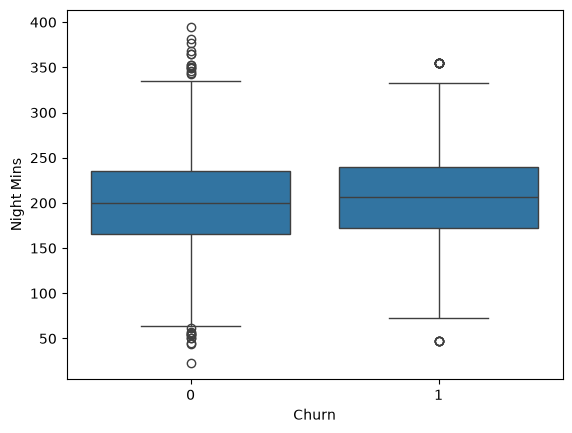

In [22]:
sns.boxplot(x="Churn", y="Night Mins", data = churn)

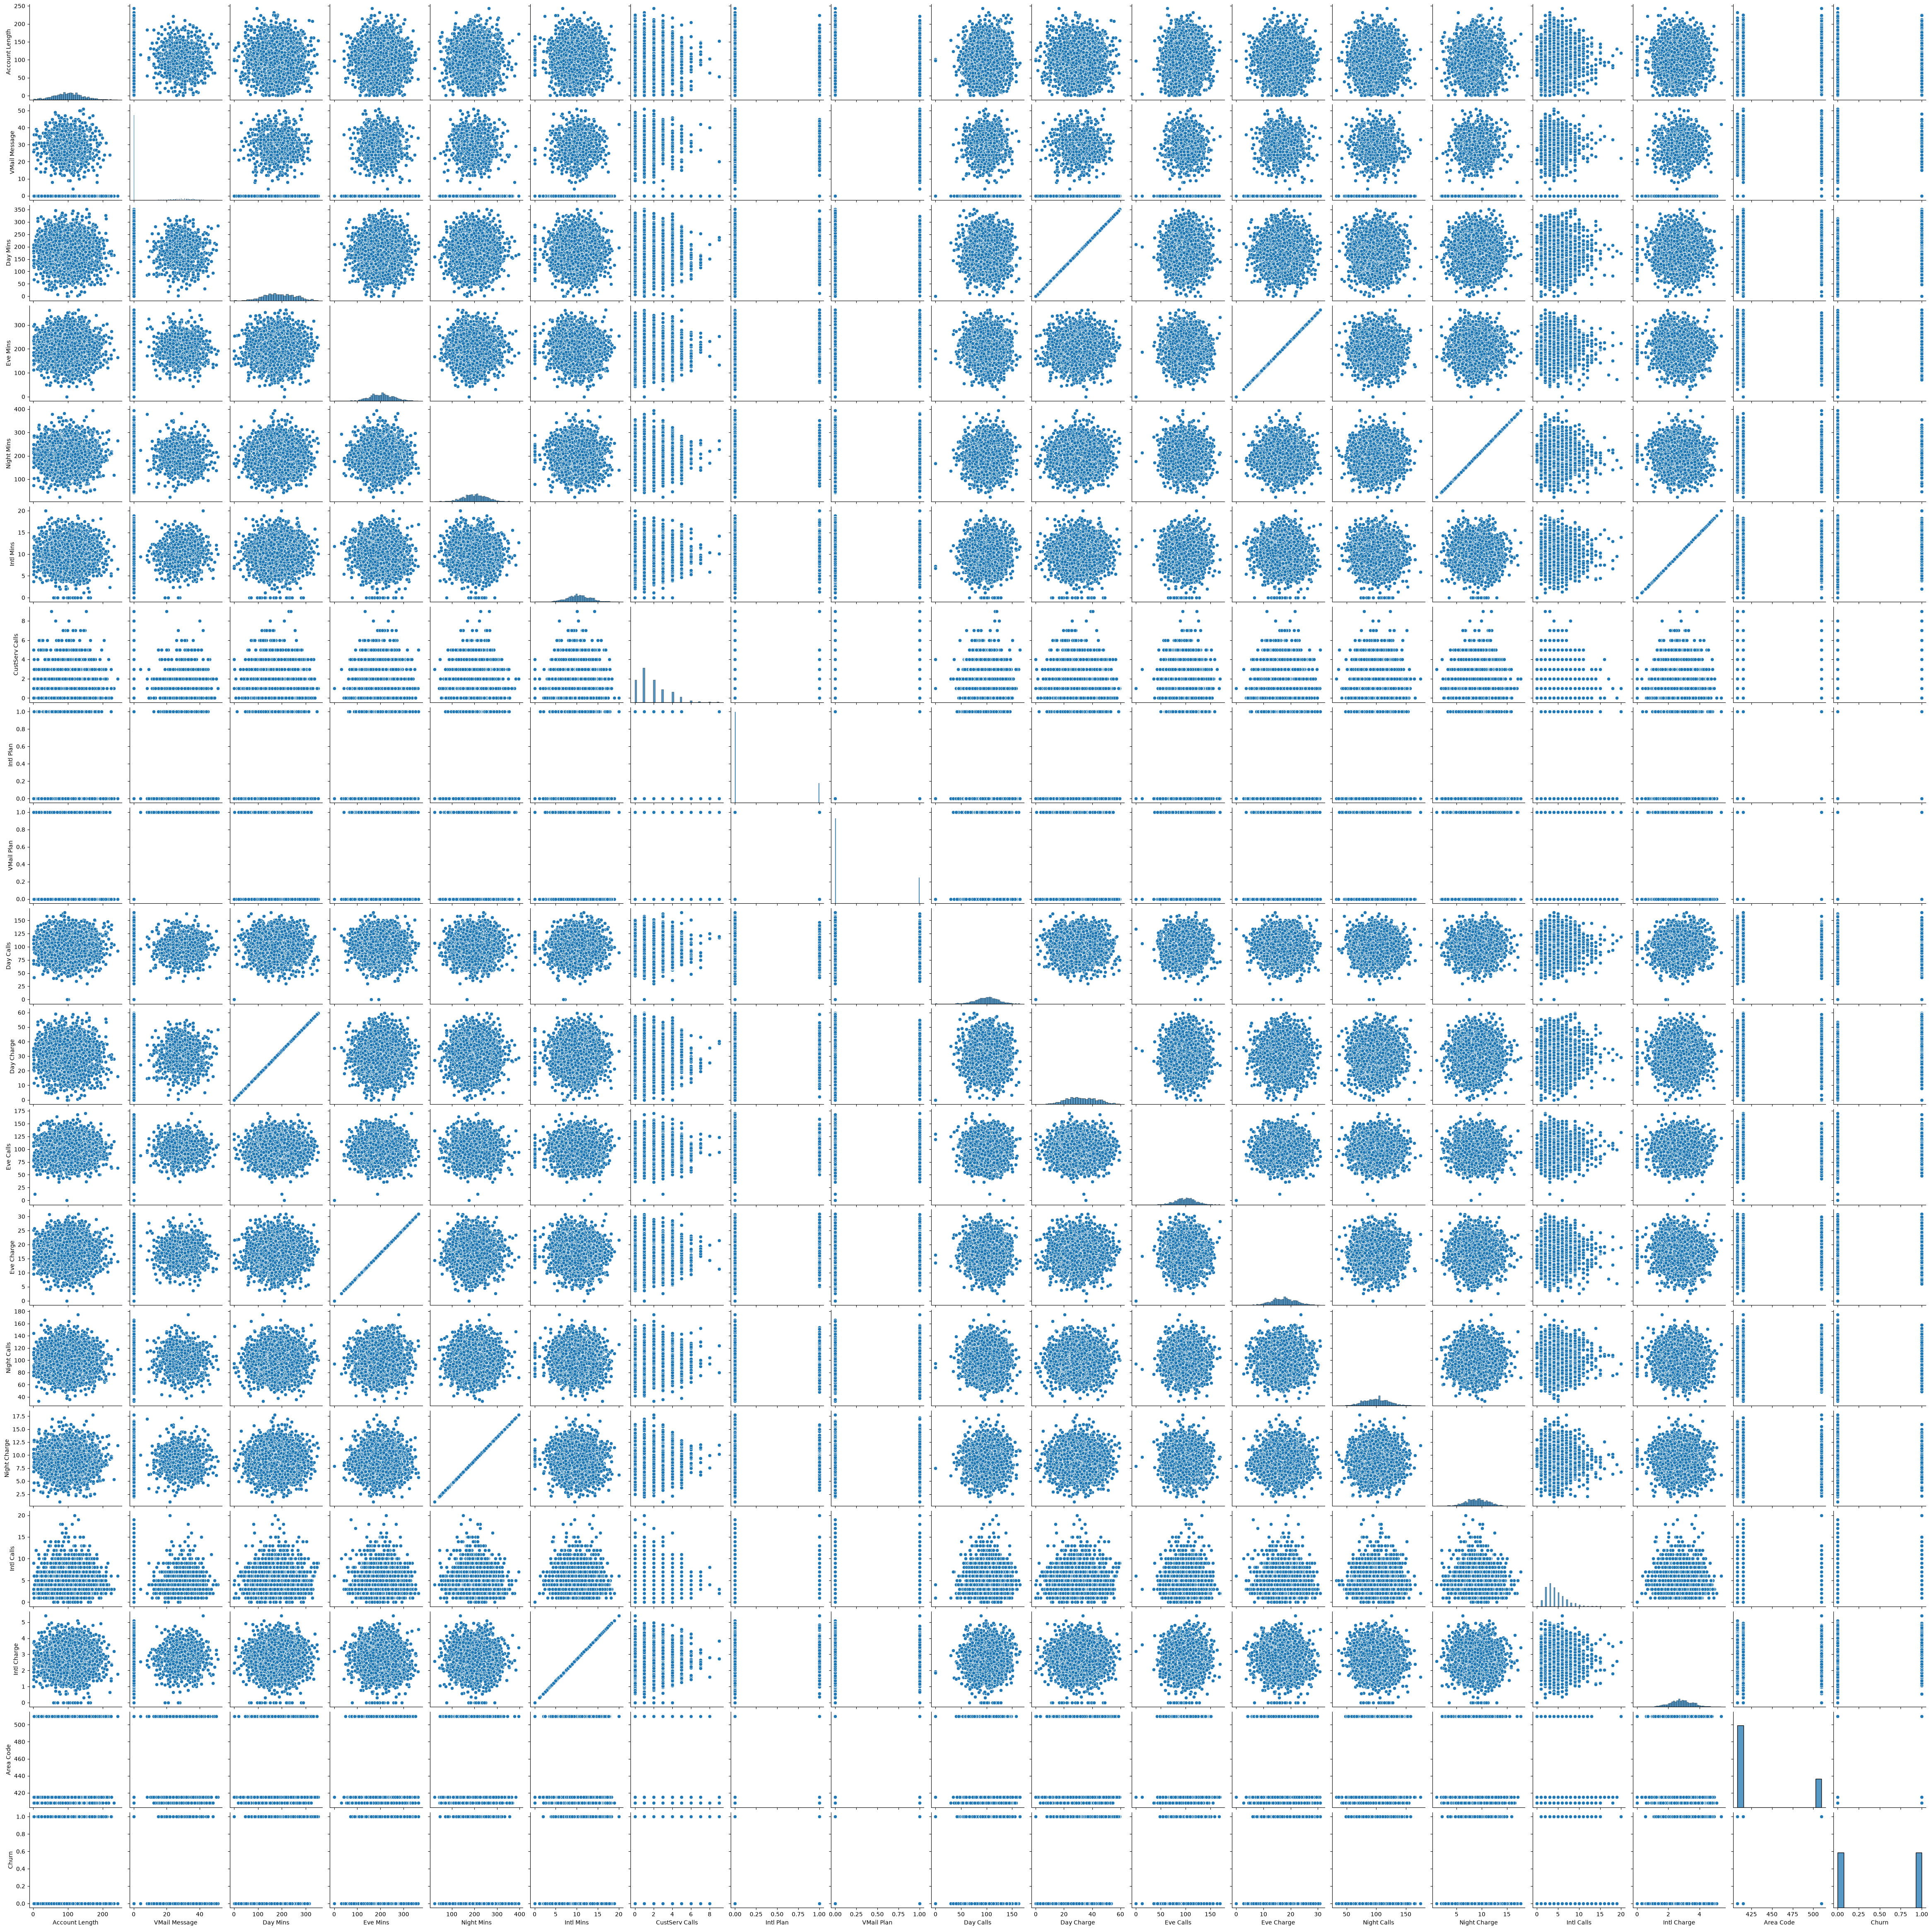

In [23]:
sns.pairplot(data=churn)